# 🔄 Notebook 2: Data Transformation & Encoding

---

## What is Data Transformation?
Machine learning models can only process **numbers**, not text. Data transformation converts raw features into formats suitable for ML models:
- **Handling missing values** (imputation)
- **Encoding categorical variables** (converting text → numbers)
- **Feature scaling** (normalizing numeric ranges)

## Types of Encoding Covered

| Encoding Type | Best For | Example |
|---|---|---|
| **Label Encoding** | Binary / Ordinal categories | Male/Female → 0/1 |
| **Ordinal Encoding** | Ordered categories | Low/Med/High → 0/1/2 |
| **One-Hot Encoding** | Nominal (no order) categories | City → [NY, LA, SF] columns |

## Dataset
We continue with the **Titanic dataset** from Notebook 1.

---

## Step 1: Import Libraries

For this notebook, we need:
- **`pandas`** — data manipulation
- **`numpy`** — numerical operations
- **`sklearn.preprocessing`** — encoding and scaling utilities
- **`sklearn.impute`** — filling missing values

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing tools
from sklearn.preprocessing import (
    LabelEncoder,        # Binary / label encoding
    OrdinalEncoder,      # Ordinal (ordered) encoding
    OneHotEncoder,       # One-hot encoding
    MinMaxScaler,        # Scale features to [0, 1]
    StandardScaler       # Z-score normalization (mean=0, std=1)
)
from sklearn.impute import SimpleImputer  # Fill missing values

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

print('✅ All libraries imported!')

✅ All libraries imported!


---
## Step 2: Load and Prepare the Dataset

Load the Titanic dataset and select relevant columns for transformation.

### Key Pandas Methods:
| Method | Description |
|---|---|
| `df[['col1','col2',...]]` | Select specific columns |
| `df.copy()` | Deep copy to avoid modifying original |
| `df.isnull().sum()` | Check missing values |

In [58]:
# Load the dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
raw_df = pd.read_csv(url)

# Select relevant columns (drop less useful ones)
cols_to_keep = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = raw_df[cols_to_keep].copy()  # .copy() avoids SettingWithCopyWarning

print(f'Shape: {df.shape}')
print('\nMissing values:')
print(df.isnull().sum())

df.head()

Shape: (891, 8)

Missing values:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---
## Step 3: Handling Missing Values (Imputation)

Missing values must be handled before encoding. We use two strategies:
- **Numeric columns** → fill with **median** (robust to outliers)
- **Categorical columns** → fill with **mode** (most frequent value)

### Key Methods:
| Method | Description |
|---|---|
| `df['col'].fillna(value)` | Fill NaN with a specific value |
| `df['col'].median()` | Median of a numeric column |
| `df['col'].mode()[0]` | Most frequent value |
| `SimpleImputer(strategy='median')` | Sklearn imputer for numeric |
| `SimpleImputer(strategy='most_frequent')` | Sklearn imputer for categorical |

> ⚠️ **Important:** Always fit imputers on **training data only** to prevent data leakage.

In [59]:
# --- Method 1: Simple Pandas fillna ---
df_pandas = df.copy()

# Fill Age (numeric) with median
age_median = df_pandas['Age'].median()
df_pandas['Age'].fillna(age_median, inplace=True)

# Fill Embarked (categorical) with mode
embarked_mode = df_pandas['Embarked'].mode()[0]
df_pandas['Embarked'].fillna(embarked_mode, inplace=True)

print(f'Age filled with median: {age_median}')
print(f'Embarked filled with mode: {embarked_mode}')
print(f'\nRemaining missing values:')
print(df_pandas.isnull().sum())

Age filled with median: 28.0
Embarked filled with mode: S

Remaining missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_193048/3298562977.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pandas['Age'].fillna(age_median, inplace=True)
/tmp/ipykernel_193048/3298562977.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [60]:
# --- Method 2: Sklearn SimpleImputer (recommended for pipelines) ---
df_sklearn = df.copy()

# Numeric imputer
num_imputer = SimpleImputer(strategy='median')
df_sklearn[['Age', 'Fare']] = num_imputer.fit_transform(df_sklearn[['Age', 'Fare']])

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
df_sklearn[['Embarked']] = cat_imputer.fit_transform(df_sklearn[['Embarked']])

print('✅ Imputation complete with SimpleImputer')
print('\nMissing values after imputation:')
print(df_sklearn.isnull().sum())

# Use the sklearn version going forward
df_clean = df_sklearn.copy()

✅ Imputation complete with SimpleImputer

Missing values after imputation:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


---
## Step 4: Label Encoding

### What is Label Encoding?
Converts each unique category to a unique integer.
```
'male'   → 1
'female' → 0
```

### ✅ When to Use:
- **Binary categories** (only 2 values): male/female, yes/no, true/false
- Decision tree models (can handle label-encoded ordinal data)

### ❌ Avoid When:
- More than 2 categories with **no order** (creates false ordinal relationships)

### Key Sklearn Class:
| Class / Method | Description |
|---|---|
| `LabelEncoder()` | Instantiate encoder |
| `.fit(y)` | Learn the mapping |
| `.transform(y)` | Apply the mapping |
| `.fit_transform(y)` | Learn + apply at once |
| `.classes_` | Array of known labels |
| `.inverse_transform(y)` | Decode numbers back to labels |

In [61]:
# ---- LABEL ENCODING ----
df_label = df_clean.copy()

# Encode 'Sex' column: female=0, male=1
le = LabelEncoder()
df_label['Sex_encoded'] = le.fit_transform(df_label['Sex'])

# See the mapping
print('=== Label Encoding: Sex ===')
print(f'Classes learned: {le.classes_}')  # ['female', 'male']
print(f'Encoding map   : female→{le.transform(["female"])[0]}, male→{le.transform(["male"])[0]}')

# Show before and after
print('\nBefore vs After encoding:')
print(df_label[['Sex', 'Sex_encoded']].drop_duplicates())

# Demonstrate inverse_transform
sample_encoded = [0, 1, 0, 1]
print(f'\nDecode [0,1,0,1]: {le.inverse_transform(sample_encoded)}')

=== Label Encoding: Sex ===
Classes learned: ['female' 'male']
Encoding map   : female→0, male→1

Before vs After encoding:
      Sex  Sex_encoded
0    male            1
1  female            0

Decode [0,1,0,1]: ['female' 'male' 'female' 'male']


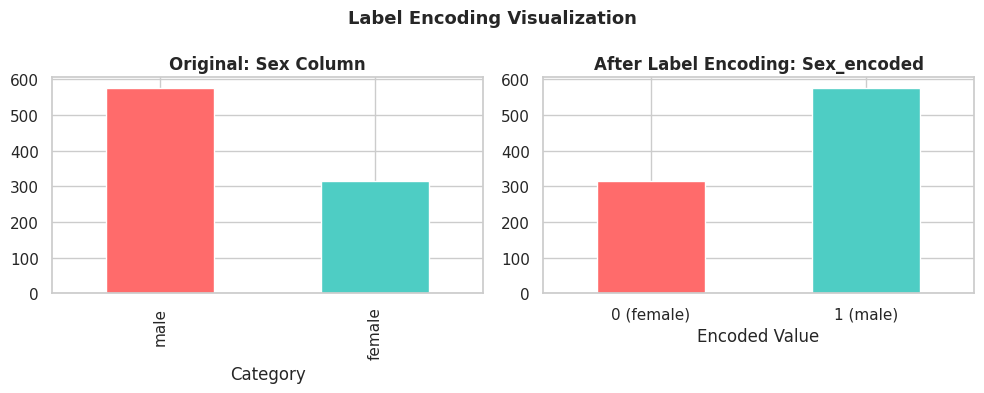

In [62]:
# Visualize the encoding effect
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_label['Sex'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Original: Sex Column', fontweight='bold')
axes[0].set_xlabel('Category')

df_label['Sex_encoded'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('After Label Encoding: Sex_encoded', fontweight='bold')
axes[1].set_xlabel('Encoded Value')
axes[1].set_xticklabels(['0 (female)', '1 (male)'], rotation=0)

plt.suptitle('Label Encoding Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5: Ordinal Encoding

### What is Ordinal Encoding?
Assigns integers that **preserve the natural order** of categories.
```
'Low'    → 0
'Medium' → 1
'High'   → 2
```

### ✅ When to Use:
- Categories that have a **clear, meaningful order**: Low/Med/High, Small/Medium/Large
- Passenger class (3rd < 2nd < 1st) is a real-world example

### ❌ Avoid When:
- There's no meaningful order (use One-Hot instead)

### Key Sklearn Class:
| Class / Method | Description |
|---|---|
| `OrdinalEncoder(categories=[...])` | Define custom order |
| `.fit_transform(X)` | Learn and apply encoding |
| `.categories_` | List of category arrays |

In [63]:
# ---- ORDINAL ENCODING ----
df_ordinal = df_clean.copy()

# Create a synthetic 'FareCategory' with natural order: Low < Medium < High < Very High
fare_bins = [0, 10, 30, 100, 600]
fare_labels = ['Low', 'Medium', 'High', 'Very High']
df_ordinal['FareCategory'] = pd.cut(df_ordinal['Fare'], bins=fare_bins, labels=fare_labels)



print('=== Original FareCategory Counts ===')
print(df_ordinal['FareCategory'].value_counts().sort_index())

=== Original FareCategory Counts ===
FareCategory
Low          321
Medium       321
High         181
Very High     53
Name: count, dtype: int64


In [64]:
df_ordinal = df_ordinal.dropna()

In [65]:
# Apply OrdinalEncoder — specify the ORDER of categories explicitly
ordered_categories = [['Low', 'Medium', 'High', 'Very High']]

oe = OrdinalEncoder(categories=ordered_categories)

# OrdinalEncoder expects 2D input, so we reshape
fc_2d = df_ordinal[['FareCategory']].astype(str)  # Convert to string for sklearn
df_ordinal['FareCategory_encoded'] = oe.fit_transform(fc_2d).astype(int)

print('=== Ordinal Encoding: FareCategory ===')
print(f'Category order : {oe.categories_[0]}')
print('\nEncoding result:')
print(df_ordinal[['FareCategory', 'FareCategory_encoded']].drop_duplicates().sort_values('FareCategory_encoded'))

=== Ordinal Encoding: FareCategory ===
Category order : ['Low' 'Medium' 'High' 'Very High']

Encoding result:
   FareCategory  FareCategory_encoded
0           Low                     0
7        Medium                     1
1          High                     2
27    Very High                     3


In [66]:
# Also show Pclass as a real ordinal example
# Pclass 1 = upper, 2 = middle, 3 = lower (already numeric, but meaningful order)
print('=== Pclass: Already Ordinal (no encoding needed) ===')
print(df_ordinal.groupby('Pclass')['Survived'].mean().mul(100).round(1))
print('\nHigher class (lower number) → higher survival rate ✅')

=== Pclass: Already Ordinal (no encoding needed) ===
Pclass
1    64.5
2    48.9
3    24.2
Name: Survived, dtype: float64

Higher class (lower number) → higher survival rate ✅


/tmp/ipykernel_193048/3480417192.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['0 (Low)', '1 (Med)', '2 (High)', '3 (V.High)'], rotation=15)


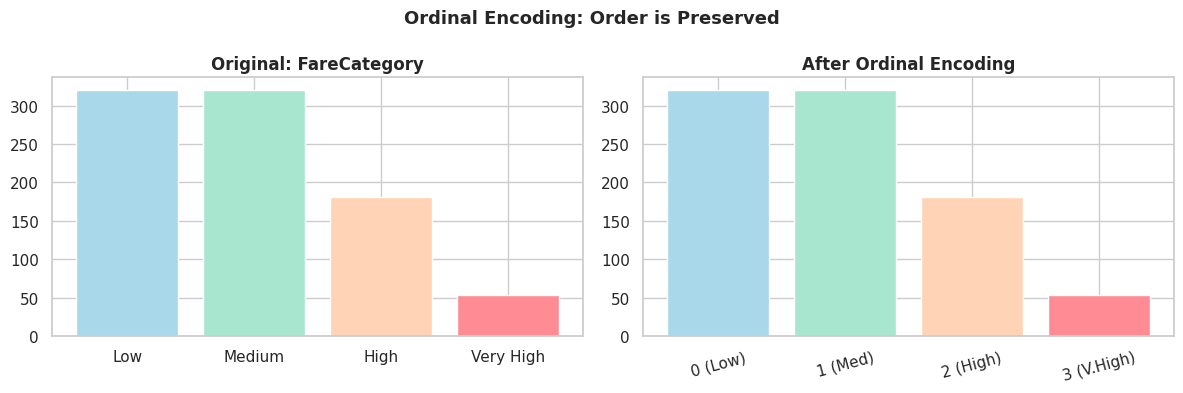

In [67]:
# Visualize ordinal encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original category distribution
order = ['Low', 'Medium', 'High', 'Very High']
counts = df_ordinal['FareCategory'].value_counts()[order]
axes[0].bar(order, counts.values, color=['#a8d8ea', '#a8e6cf', '#ffd3b6', '#ff8b94'])
axes[0].set_title('Original: FareCategory', fontweight='bold')

# Encoded distribution
enc_counts = df_ordinal['FareCategory_encoded'].value_counts().sort_index()
axes[1].bar(enc_counts.index.astype(str), enc_counts.values, color=['#a8d8ea', '#a8e6cf', '#ffd3b6', '#ff8b94'])
axes[1].set_title('After Ordinal Encoding', fontweight='bold')
axes[1].set_xticklabels(['0 (Low)', '1 (Med)', '2 (High)', '3 (V.High)'], rotation=15)

plt.suptitle('Ordinal Encoding: Order is Preserved', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6: One-Hot Encoding

### What is One-Hot Encoding?
Creates a **new binary column for each category**. Only one column is "hot" (=1) per row.

```
Embarked=C → [1, 0, 0]
Embarked=Q → [0, 1, 0]
Embarked=S → [0, 0, 1]
```

### ✅ When to Use:
- Categories with **no natural order**: city names, colors, countries, ports
- Linear models (they require this!)

### ⚠️ Dummy Variable Trap:
- Drop one column (`drop='first'` or `drop_first=True`) to avoid multicollinearity

### Key Methods:
| Method | Description |
|---|---|
| `pd.get_dummies(df, columns=[...])` | Pandas one-hot encoding |
| `pd.get_dummies(df, drop_first=True)` | Drop first category (avoid trap) |
| `OneHotEncoder(drop='first')` | Sklearn OHE |
| `OneHotEncoder(sparse_output=False)` | Return dense array |
| `.get_feature_names_out()` | Get column names |

In [68]:
# ---- METHOD 1: Pandas get_dummies ----
df_ohe_pandas = df_clean.copy()

# Encode 'Embarked' (3 categories: C, Q, S)
df_ohe_pandas = pd.get_dummies(
    df_ohe_pandas,
    columns=['Embarked'],
    drop_first=False,   # Set True to avoid dummy variable trap
    dtype=int            # Use integer (0/1) instead of bool
)

print('=== One-Hot Encoding with pd.get_dummies ===')
print('New columns created:', [c for c in df_ohe_pandas.columns if 'Embarked' in c])
print('\nSample rows:')
df_ohe_pandas[['Survived'] + [c for c in df_ohe_pandas.columns if 'Embarked' in c]].head(8)

=== One-Hot Encoding with pd.get_dummies ===
New columns created: ['Embarked_C', 'Embarked_Q', 'Embarked_S']

Sample rows:


,Survived,Embarked_C,Embarked_Q,Embarked_S
0,0,0,0,1
1,1,1,0,0
2,1,0,0,1
3,1,0,0,1
4,0,0,0,1
5,0,0,1,0
6,0,0,0,1
7,0,0,0,1


In [69]:
# ---- METHOD 2: Sklearn OneHotEncoder ----
df_ohe_sk = df_clean.copy()

ohe = OneHotEncoder(
    drop='first',          # Drop first category to avoid multicollinearity
    sparse_output=False,   # Return a regular numpy array
    dtype=int
)

# Fit and transform
embarked_encoded = ohe.fit_transform(df_ohe_sk[['Embarked']])
feature_names = ohe.get_feature_names_out(['Embarked'])

print('=== OneHotEncoder Feature Names ===')
print(feature_names)

# Add encoded columns back to dataframe
embarked_df = pd.DataFrame(embarked_encoded, columns=feature_names, index=df_ohe_sk.index)
df_ohe_sk = pd.concat([df_ohe_sk.drop('Embarked', axis=1), embarked_df], axis=1)

print('\nNew shape after OHE:', df_ohe_sk.shape)
print('\nSample (Embarked columns):')
print(df_ohe_sk[list(feature_names)].head(5))

=== OneHotEncoder Feature Names ===
['Embarked_Q' 'Embarked_S']

New shape after OHE: (891, 9)

Sample (Embarked columns):
   Embarked_Q  Embarked_S
0           0           1
1           0           0
2           0           1
3           0           1
4           0           1


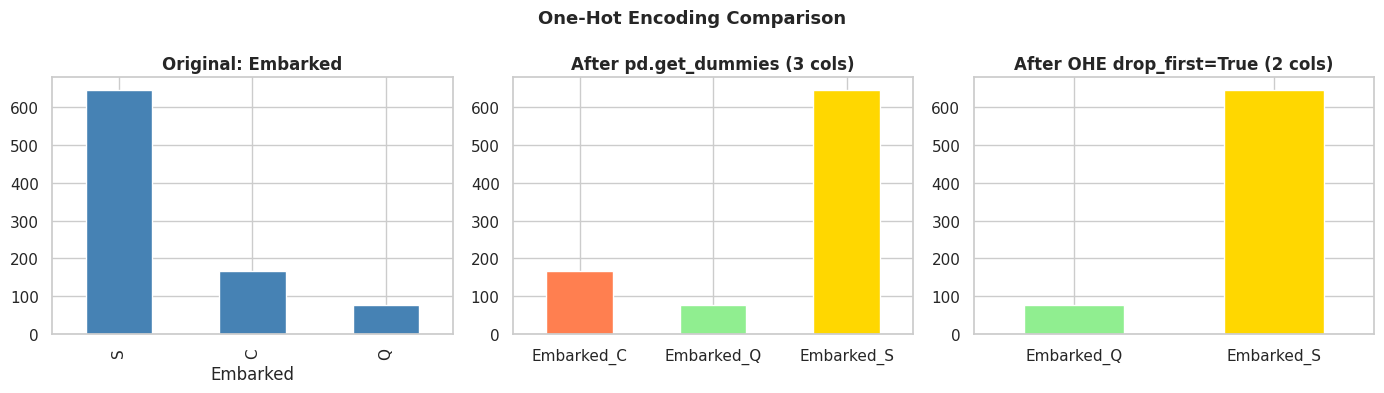

In [70]:
# Visualize the difference between approaches
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original Embarked
df_clean['Embarked'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original: Embarked', fontweight='bold')

# After OHE (pd.get_dummies) - show distribution of 3 new columns
ohe_cols = [c for c in df_ohe_pandas.columns if 'Embarked' in c]
df_ohe_pandas[ohe_cols].sum().plot(kind='bar', ax=axes[1], color=['coral','lightgreen','gold'])
axes[1].set_title('After pd.get_dummies (3 cols)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# After OHE (sklearn, drop first)
feature_names_list = list(feature_names)
df_ohe_sk[feature_names_list].sum().plot(kind='bar', ax=axes[2], color=['lightgreen','gold'])
axes[2].set_title('After OHE drop_first=True (2 cols)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('One-Hot Encoding Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Encoding Comparison — Side by Side

Compare all three encoding strategies on the same data.

In [71]:
# Show all three encoding approaches on a small sample
sample = df_clean[['Sex', 'Embarked']].head(8).reset_index(drop=True)

# Label Encoding
le_sex = LabelEncoder()
sample['Sex_Label'] = le_sex.fit_transform(sample['Sex'])

# Ordinal Encoding (treat Embarked as ordinal just for demo)
oe_emb = OrdinalEncoder(categories=[['C', 'Q', 'S']])
sample['Embarked_Ordinal'] = oe_emb.fit_transform(sample[['Embarked']]).astype(int)

# One-Hot Encoding
ohe_demo = pd.get_dummies(sample[['Embarked']], prefix='Emb', dtype=int)
sample = pd.concat([sample, ohe_demo], axis=1)

print('=== Encoding Comparison (first 8 rows) ===')
print(sample.to_string())
print('\n📌 Note:')
print('  Label     : 1 number per row (Male=1, Female=0)')
print('  Ordinal   : 1 number per row (order preserved)')
print('  One-Hot   : 1 column per category (only one = 1 per row)')

=== Encoding Comparison (first 8 rows) ===
      Sex Embarked  Sex_Label  Embarked_Ordinal  Emb_C  Emb_Q  Emb_S
0    male        S          1                 2      0      0      1
1  female        C          0                 0      1      0      0
2  female        S          0                 2      0      0      1
3  female        S          0                 2      0      0      1
4    male        S          1                 2      0      0      1
5    male        Q          1                 1      0      1      0
6    male        S          1                 2      0      0      1
7    male        S          1                 2      0      0      1

📌 Note:
  Label     : 1 number per row (Male=1, Female=0)
  Ordinal   : 1 number per row (order preserved)
  One-Hot   : 1 column per category (only one = 1 per row)


---
## Step 8: Feature Scaling

Many ML algorithms (logistic regression, KNN, SVM) are **sensitive to feature magnitude**. A 'Fare' of 512 would dominate 'Age' of 25 without scaling.

### Two Common Scalers:

| Scaler | Formula | Output Range | Best For |
|---|---|---|---|
| `MinMaxScaler` | (x - min) / (max - min) | [0, 1] | When bounded range needed |
| `StandardScaler` | (x - mean) / std | mean=0, std=1 | Normally distributed data |

### Key Sklearn Methods:
| Method | Description |
|---|---|
| `.fit(X_train)` | Compute min/max or mean/std from training data |
| `.transform(X)` | Apply scaling |
| `.fit_transform(X)` | Fit + transform in one step |
| `.inverse_transform(X)` | Reverse the scaling |

In [72]:
# Apply scaling to numeric columns
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# --- MinMax Scaler ---
mm_scaler = MinMaxScaler()  # Scales to [0, 1]
df_minmax = df_clean.copy()
df_minmax[numeric_cols] = mm_scaler.fit_transform(df_clean[numeric_cols])

# --- Standard Scaler ---
std_scaler = StandardScaler()  # Scales to mean=0, std=1
df_standard = df_clean.copy()
df_standard[numeric_cols] = std_scaler.fit_transform(df_clean[numeric_cols])

print('=== Original Stats ===')
print(df_clean[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

print('\n=== After MinMaxScaler (all in [0,1]) ===')
print(df_minmax[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

print('\n=== After StandardScaler (mean≈0, std≈1) ===')
print(df_standard[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

=== Original Stats ===
        Age    Fare  SibSp  Parch
mean  29.36   32.20   0.52   0.38
std   13.02   49.69   1.10   0.81
min    0.42    0.00   0.00   0.00
max   80.00  512.33   8.00   6.00

=== After MinMaxScaler (all in [0,1]) ===
       Age  Fare  SibSp  Parch
mean  0.36  0.06   0.07   0.06
std   0.16  0.10   0.14   0.13
min   0.00  0.00   0.00   0.00
max   1.00  1.00   1.00   1.00

=== After StandardScaler (mean≈0, std≈1) ===
       Age  Fare  SibSp  Parch
mean  0.00  0.00   0.00   0.00
std   1.00  1.00   1.00   1.00
min  -2.22 -0.65  -0.47  -0.47
max   3.89  9.67   6.78   6.97


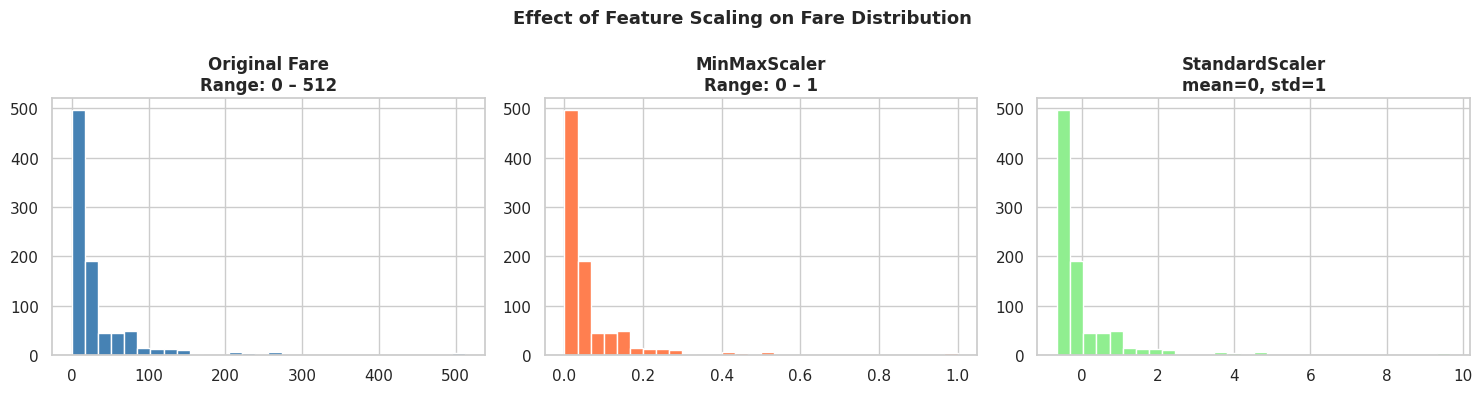

💡 Shape is preserved — only the range changes!


In [73]:
# Visualize scaling effect on 'Fare'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['Fare'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original Fare\nRange: {df_clean["Fare"].min():.0f} – {df_clean["Fare"].max():.0f}', fontweight='bold')

axes[1].hist(df_minmax['Fare'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('MinMaxScaler\nRange: 0 – 1', fontweight='bold')

axes[2].hist(df_standard['Fare'], bins=30, color='lightgreen', edgecolor='white')
axes[2].set_title('StandardScaler\nmean=0, std=1', fontweight='bold')

plt.suptitle('Effect of Feature Scaling on Fare Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Shape is preserved — only the range changes!')

---
## Step 9: Build the Final Transformed Dataset

Combine all transformations into one clean, model-ready DataFrame.

In [74]:
# ---- FULL PIPELINE: All transformations in one place ----

df_final = df_clean.copy()

# 1. Label Encode: Sex (binary)
le_sex = LabelEncoder()
df_final['Sex'] = le_sex.fit_transform(df_final['Sex'])  # female=0, male=1

# 2. One-Hot Encode: Embarked (nominal, 3 categories)
embarked_dummies = pd.get_dummies(df_final['Embarked'], prefix='Embarked', drop_first=True, dtype=int)
df_final = pd.concat([df_final.drop('Embarked', axis=1), embarked_dummies], axis=1)

# 3. Standard Scale: numeric columns
scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = StandardScaler()
df_final[scale_cols] = scaler.fit_transform(df_final[scale_cols])

print('=== Final Transformed DataFrame ===')
print(f'Shape: {df_final.shape}')
print(f'Columns: {list(df_final.columns)}')
print(f'Missing values: {df_final.isnull().sum().sum()}')
print()
df_final.head()

=== Final Transformed DataFrame ===
Shape: (891, 9)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Missing values: 0



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,0,1
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,0,0
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,0,1
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,0,1


In [75]:
# Save the transformed dataset for use in Notebook 3
df_final.to_csv('titanic_transformed.csv', index=False)
print('✅ Saved as titanic_transformed.csv')
print('\n📌 Summary of all transformations applied:')
print('  1. Missing values filled (median for Age, mode for Embarked)')
print('  2. Sex: Label Encoded (female=0, male=1)')
print('  3. Embarked: One-Hot Encoded (drop_first=True → 2 dummy columns)')
print('  4. Numeric features: Standard Scaled (mean=0, std=1)')
print()
print('→ Next: Notebook 3 — Model Training with Classification Models')

✅ Saved as titanic_transformed.csv

📌 Summary of all transformations applied:
  1. Missing values filled (median for Age, mode for Embarked)
  2. Sex: Label Encoded (female=0, male=1)
  3. Embarked: One-Hot Encoded (drop_first=True → 2 dummy columns)
  4. Numeric features: Standard Scaled (mean=0, std=1)

→ Next: Notebook 3 — Model Training with Classification Models


---
## 📚 Quick Reference: Methods Used in this Notebook

### Pandas
| Method | Description |
|---|---|
| `df.copy()` | Deep copy to prevent modifying original |
| `df['col'].fillna(val)` | Fill missing values |
| `df['col'].median()` | Median value |
| `df['col'].mode()[0]` | Most frequent value |
| `pd.get_dummies(df, columns=[...])` | One-hot encoding |
| `pd.cut(col, bins, labels)` | Bin numeric to categorical |
| `pd.concat([df1, df2], axis=1)` | Concatenate DataFrames side-by-side |

### Scikit-Learn
| Class | Method | Description |
|---|---|---|
| `SimpleImputer` | `fit_transform()` | Fill missing values |
| `LabelEncoder` | `fit_transform()`, `.classes_` | Binary encoding |
| `OrdinalEncoder` | `fit_transform()`, `.categories_` | Ordered encoding |
| `OneHotEncoder` | `fit_transform()`, `.get_feature_names_out()` | Dummy encoding |
| `MinMaxScaler` | `fit_transform()` | Scale to [0,1] |
| `StandardScaler` | `fit_transform()` | Z-score normalization |